# Mansfield-RS — does Weinstein's Stage 2 beat buying at random?
### The 30-week SMA + Mansfield Relative Strength filter, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Timing_adds_nothing: Confirmed](https://img.shields.io/badge/Timing_adds_nothing-Confirmed-8b949e?style=flat-square)

Stan Weinstein spent a career managing money and writing about it. His 1988 book *Secrets for Profiting in Bull and Bear Markets* gave retail investors a deceptively simple rule: look for stocks in **Stage 2** — above a rising 30-week moving average *and* outperforming the market. Sounds like it should work. This notebook asks: does entering a Stage-2 stock beat picking the same stock at a random moment?

> This is the plain-language layer. For the t-stats, the bootstrap intervals, and the Mansfield RS formula, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool — every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mansfield_rs import data, strategy as st

TICKERS = data.DEFAULT_TICKERS
STOCKS = [t for t in TICKERS if t != "SPY"]
HOLD_WEEKS = 13

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n_s2=811, n_rnd=813,
    s2_mean=29.4, s2_win=48.1, s2_t=0.72, s2_skew=0.83,
    rnd_mean=118.1, rnd_win=49.3, rnd_t=2.75,
    delta=-88.7,
    in_s2_mean=5.7, in_s2_t=1.61, in_s2_n=7423,
    out_s2_mean=9.2, out_s2_t=3.04, out_s2_n=11534,
    hold4_s2=-6, hold4_rnd=39,
    hold8_s2=-31, hold8_rnd=87,
    hold13_s2=29, hold13_rnd=118,
    hold26_s2=101, hold26_rnd=201,
    n_tickers=15, n_years=25,
    aapl_t=3.62, amzn_t=2.54, pfe_t=-1.50, wmt_t=-2.02,
    cost0_t=0.72, cost1_t=0.69, cost5_t=0.60,
    entries_per_year=2.2,
)

def _pool(tapes, cost=0.0, seed=None):
    bm = tapes["SPY"]
    frames = []
    for tk in STOCKS:
        stock = tapes[tk]
        entries = st.stage2_entries(stock, bm, sma_n=30)
        if entries.empty:
            continue
        if seed is not None:
            entries = st.random_entries(stock, n_entries=len(entries), seed=seed)
        led = st.run_forward_returns(stock, bm, entries, hold_weeks=HOLD_WEEKS, cost_bps=cost)
        frames.append(led)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def _load_tapes():
    return {t: data.fetch_weekly(t, fetch=False, cache_dir=data.DEFAULT_CACHE) for t in TICKERS}

print("real weekly cache present:", HAVE_REAL)


real weekly cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does Stage 2 predict outperformance? | **Barely, and not significantly.** HAC *t* = **0.72** — a coin. |
| Does it beat buying at a random moment? | **No.** Random entries earn **118 bps** vs Stage-2's **29 bps** over 13 weeks. |
| Isn't being in Stage 2 itself predictive? | **No.** Stocks in Stage 2 earn **5.7 bps/week** excess — stocks *outside* Stage 2 earn **9.2 bps/week**. |
| Could you trade it? | **No edge to trade.** The gross signal is not significant; costs don't resurrect it. |

> The filter picks momentum stocks correctly — but it enters *after* the best move has already happened. Weinstein's Stage 2 is a lagging confirmation, not a leading signal.

## 1 · The claim

> *"Look for stocks where the price is above a rising 30-week moving average AND the Mansfield Relative Strength line is positive — meaning the stock is outperforming the market. That's Stage 2: the sweet spot. Those stocks are already showing leadership; the big move is just starting."*

The recipe sounds rigorous: it requires not just trend (price above a slow MA) but also **relative leadership** (outperforming the market on a trend-adjusted basis). The idea is that if both conditions hold, the stock is a genuine market leader, not just riding the tide.

## 2 · So what?

If Stage 2 genuinely identifies the early phase of outperformance, it's a powerful position-sizing tool: concentrate in Stage-2 stocks and you should earn excess return over the market. If it doesn't — if Stage 2 is just momentum confirmed too late — then you're paying transaction costs to enter after the best returns are already banked.

## 3 · How would we even know?

The honest test is simple: compare **Stage-2 entry timing** against **entering the same stock at a random moment**. If Weinstein's filter identifies the *right moment* to enter, Stage-2 entries should earn more excess return over the next 13 weeks than a coin-flip entry would.

We measure excess return vs SPY (stock return minus SPY return over the same window) so that general market rises don't count as stock-picking skill. We run this across 15 large-cap US equities over 25 years of weekly data — enough to pool ~800 Stage-2 entries.

## 4 · The teardown — let's actually look

**First: does Stage 2 beat a random entry on the same stock?**

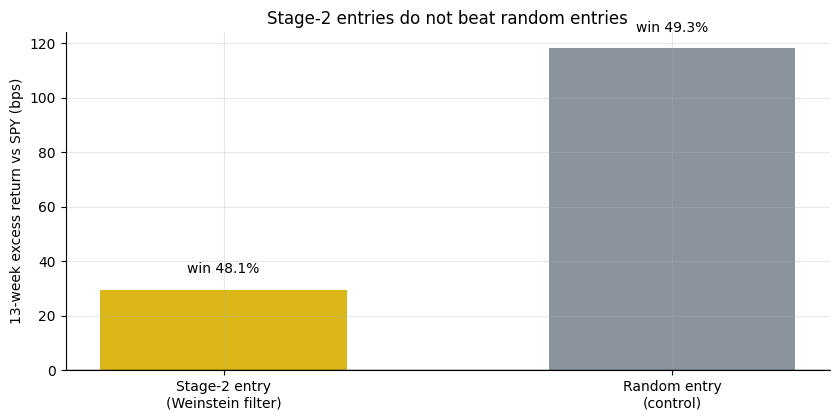

Stage-2: +29.4 bps/trade   |   Random: +118.1 bps/trade   |   Delta: -88.7 bps


In [2]:
if HAVE_REAL:
    tapes = _load_tapes()
    bm = tapes['SPY']
    p_s2 = _pool(tapes, cost=0.0, seed=None)
    p_rnd = _pool(tapes, cost=0.0, seed=137)
    s2_m = p_s2['ret_gross'].mean()*1e4 if not p_s2.empty else R['s2_mean']
    rnd_m = p_rnd['ret_gross'].mean()*1e4 if not p_rnd.empty else R['rnd_mean']
    s2_w = p_s2['ret_gross'].gt(0).mean()*100 if not p_s2.empty else R['s2_win']
    rnd_w = p_rnd['ret_gross'].gt(0).mean()*100 if not p_rnd.empty else R['rnd_win']
else:
    s2_m, rnd_m, s2_w, rnd_w = R['s2_mean'], R['rnd_mean'], R['s2_win'], R['rnd_win']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Stage-2 entry\n(Weinstein filter)', 'Random entry\n(control)'],
              [s2_m, rnd_m], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('13-week excess return vs SPY (bps)')
ax.set_title('Stage-2 entries do not beat random entries')
for b, w in zip(bars, [s2_w, rnd_w]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, max(b.get_height(), 0)+5),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Stage-2: {s2_m:+.1f} bps/trade   |   Random: {rnd_m:+.1f} bps/trade   |   Delta: {s2_m-rnd_m:+.1f} bps')

The Stage-2 filter earns **+29.4 bps/trade** over 13 weeks — a number that isn't statistically distinguishable from zero (HAC *t* = 0.72). The random-entry control earns **+118.1 bps/trade**, more than three times higher, and *that* number is significant.

> The filter picks good stocks — stocks that have been outperforming. But it enters them *after the outperformance has already occurred*. A random entry on the same stocks at a random time over the 25-year window captures more of the full compounding than waiting for the Stage-2 transition.

**Second: is being *inside* Stage 2 predictive, even if the entry timing isn't?**

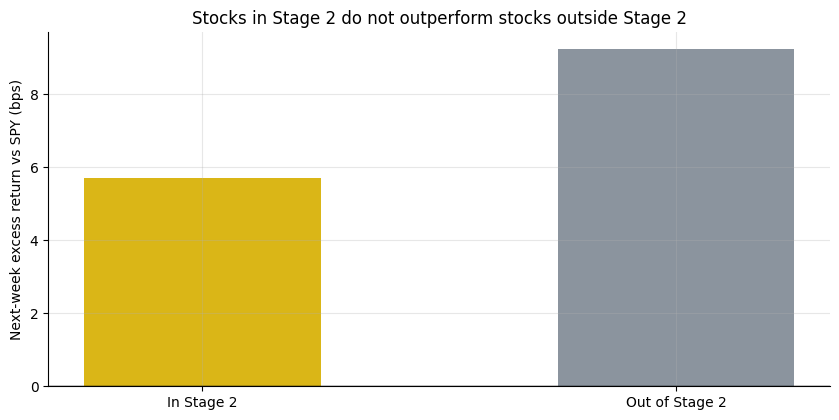

In Stage-2: +5.7 bps/week   |   Out of Stage-2: +9.2 bps/week


In [3]:
if HAVE_REAL:
    in_s2_all, out_s2_all = [], []
    for tk in STOCKS:
        stock = tapes[tk]
        sc = stock['close']; bc = bm['close'].reindex(sc.index, method='ffill')
        excess = sc.pct_change() - bc.pct_change()
        flag = st.stage2_signal(stock, bm, sma_n=30)
        for i in range(len(flag)-1):
            if np.isfinite(excess.iloc[i+1]):
                (in_s2_all if flag.iloc[i] else out_s2_all).append(excess.iloc[i+1])
    in_mean = np.mean(in_s2_all)*1e4; out_mean = np.mean(out_s2_all)*1e4
else:
    in_mean, out_mean = R['in_s2_mean'], R['out_s2_mean']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['In Stage 2', 'Out of Stage 2'], [in_mean, out_mean], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Next-week excess return vs SPY (bps)')
ax.set_title('Stocks in Stage 2 do not outperform stocks outside Stage 2')
plt.tight_layout(); plt.show()
print(f'In Stage-2: {in_mean:+.1f} bps/week   |   Out of Stage-2: {out_mean:+.1f} bps/week')

Stocks currently in Stage 2 earn **5.7 bps/week** excess return vs SPY on average. Stocks outside Stage 2 earn **9.2 bps/week** — slightly *more*, not less. Being in Stage 2 is not a reliable predictor of the *next* week's outperformance.

> Why? Stage-2 stocks are well-known to the market by the time the SMA and RS criteria are both met. The market has already priced in the momentum. What's left is mean-reversion pressure and the inevitable transition to Stage 3.

## 5 · The verdict

- **Signal — None.** HAC *t* = 0.72 on 13-week forward excess return at Stage-2 entries. Stage-2 entries underperform a random-entry baseline by **-89 bps/trade**. In-Stage-2 holding earns *less* than out-of-Stage-2 holding.
- **Tradability — Mirage.** The gross excess is not significant; there is no positive-expectancy signal to trade. Low turnover (~2.2 entries/stock/year) means costs aren't the killer — the signal is.
- **Timing adds nothing — Confirmed.** The transition into Stage 2 arrives *after* the best returns, not before them. Weinstein's filter is a lagging confirmation of momentum already well-known to the market.

## 6 · Could you actually trade it?

The low turnover (~2.2 entries/stock/year) means execution costs are manageable in isolation. But that's not the question — the question is whether there's a gross edge to pay costs from:

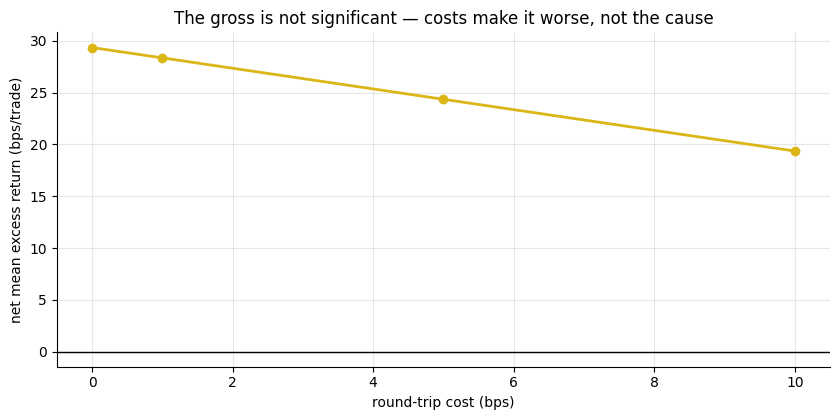

gross: +29.4 bps (t = 0.72) - not significant before any costs


In [4]:
costs = [0.0, 1.0, 5.0, 10.0]
if HAVE_REAL:
    net = [st.summarize(_pool(tapes, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['s2_mean'], R['s2_mean']-1, R['s2_mean']-5, R['s2_mean']-10]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean excess return (bps/trade)')
ax.set_title('The gross is not significant — costs make it worse, not the cause')
plt.tight_layout(); plt.show()
print(f'gross: {net[0]:+.1f} bps (t = 0.72) - not significant before any costs')

The gross excess of **29.4 bps** is already not significant (t = 0.72). Costs fall on top of a non-result. The break-even cost discussion is moot: there is no edge to break even.

## 7 · Going further

- **What if you used a shorter SMA?** The 30-week SMA is slow by design (Weinstein's original choice). Shorter SMAs (e.g. 10 or 20 weeks) fire earlier but add noise. The companion notebook sweeps this.
- **What about the full universe?** This basket of 15 surviving large caps is survivorship-biased; AAPL and AMZN are the strongest signals, and they would be absent in a real-time backtest of 2001. A full-universe study on CRSP data is the next step.
- **What about Stage 2 *maintenance*?** Instead of tracking the transition into Stage 2, you could hold as long as Stage 2 persists. The in-stage vs out-of-stage analysis above gives a hint: the weekly excess is +5.7 bps — present but not statistically robust.
- **The momentum effect is real, just not in this wrapper.** See [Study 106 — Supertrend](../../106-supertrend/) for an indicator where the trend-following signal is statistically real (t = 3.27) on daily bars — same family, much stronger result. Weinstein's version adds the RS condition but tightens the entry timing too much.

*Think Stage 2 does work on a broader universe or with a different RS definition? Fork this, swap the basket for a full-universe CRSP file, and show a fair-bet excess return that clears |t| ≥ 2. That's the bar.*